##  Orchestration

Our first Agentic Framework project!!

### Part 1: Email Setup

### Part 2: Orchestrating by code

### Part 3: Orchestrating by LLMs

- 3a: via Tools
- 3b: via Handoffs

## Part 1: Email Setup

## Setting up to send emails from your SMTP server

### STEP 1: Determining your SMTP Server

Either google or ask ChatGPT / Claude for the SMTP server for your email. Here are some common ones. Some email providers might not have SMTP servers enabled (eg Microsoft 365 for work/school).

Google: smtp.gmail.com  
Outlook.com / Hotmail / Live: smtp-mail.outlook.com  
Microsoft 365: smtp.office365.com  
iCloud Mail: smtp.mail.me.com  

Add to your .env file:  

`EMAIL_SMTP_SERVER=xxxx`

### STEP 2: Obtain an app specific password

Google how to do this for your email provider. For gmail, you need to have 2-step verification on. Then visit this page:

https://myaccount.google.com/apppasswords

Give it any name; copy the password and add it to your .env file, removing the spaces that it adds. (It should be 16 characters, no spaces.)

`EMAIL_APP_PASSWORD=xxxx`

### STEP 3: Add in your email address:

`EMAIL_ADDRESS=xxx`

Remember to Save the .env file!

In [30]:
from openai import AsyncOpenAI
from agents.models.openai_chatcompletions import OpenAIChatCompletionsModel
import os

print("GROQ_API_KEY loaded:", os.getenv("GROQ_API_KEY") is not None)

groq_client = AsyncOpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
)

model = OpenAIChatCompletionsModel(
    model="llama-3.3-70b-versatile",
    openai_client=groq_client,
)

print("Model created successfully!")

GROQ_API_KEY loaded: True
Model created successfully!


In [31]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)
MODEL_NAME = "llama-3.3-70b-versatile"

In [32]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


In [33]:
# Here we go

def send_email(subject, text_body, html_body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [34]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

### If this didn't work, then uncomment the below so that we don't use emails

In [19]:
# USE_EMAIL = False

### Our fallback strategy - send a push

In [35]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

Pushover user found and looks good
Pushover token found and looks good


In [36]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [37]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

### OK Now everything should work!

In [38]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

## Agent Orchestration

There are 2 models for Agent Orchestration; by code and by LLMs.

By code: more predictable and deterministic.

By LLMs: more powerful.

An excellent write-up is here:

https://openai.github.io/openai-agents-python/multi_agent/

We will start with by Code.

## Part 2: Orchestrating by Code

In [39]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [40]:
print(model)


In [41]:
sales_agent1 = Agent(
    name="Professional Sales Agent",
    instructions=instructions1,
    model=model,
)

sales_agent2 = Agent(
    name="Humorous Sales Agent",
    instructions=instructions2,
    model=model,
)

sales_agent3 = Agent(
    name="Executive Sales Agent",
    instructions=instructions3,
    model=model,
)

In [42]:

result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Enhance Your SOC2 Compliance with AI-Driven Insights

Dear [Recipient's Name],

I am reaching out from ComplAI, a leading provider of SaaS solutions dedicated to streamlining SOC2 compliance and audit preparedness. Our cutting-edge, AI-powered platform is designed to help organizations like yours navigate the complexities of regulatory requirements, ensuring the highest standards of security, availability, processing integrity, confidentiality, and privacy.

As a [Recipient's Job Title] at [Company Name], you understand the significance of maintaining stringent security controls and procedures to protect sensitive data and uphold stakeholder trust. However, managing SOC2 compliance can be a daunting task, often requiring substantial resources and expertise.

Our ComplAI platform is specifically engineered to mitigate these challenges. By leveraging artificial intelligence, we provide:

1. **Automated Compliance Monitoring**: Continuous assessment and identification of complian

OPENAI_API_KEY is not set, skipping trace export


In [43]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")


Subject: Enhance Your Security Posture with ComplAI's SOC2 Compliance Solution

Dear [Recipient's Name],

I am writing to introduce ComplAI, a cutting-edge SaaS tool designed to streamline SOC2 compliance and audit preparation for organizations like yours. As a [Job Title] at [Company Name], I'm sure you understand the importance of maintaining a robust security posture in today's ever-evolving regulatory landscape.

ComplAI's innovative AI-powered platform helps companies achieve and maintain SOC2 compliance, reducing the burden of manual processes and minimizing the risk of non-compliance. Our solution provides real-time monitoring, automated evidence collection, and intuitive reporting, making it easier to demonstrate compliance to auditors and stakeholders.

By leveraging ComplAI, your organization can:

* Reduce the time and cost associated with SOC2 audit preparation
* Enhance the accuracy and efficiency of compliance reporting
* Strengthen internal controls and risk management p

OPENAI_API_KEY is not set, skipping trace export


In [44]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=model)


In [45]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")


Best sales email:
Subject: Don't Let SOC2 Audits Haunt You

Dear [Recipient's Name],

Are SOC2 audits keeping you up at night? Do you lie awake, wondering if your company's security controls are up to par? Well, put down that glass of warm milk and take a deep breath. We've got a solution that'll make you sleep like a baby (or at least, like a well-rested compliance officer).

At ComplAI, we've developed an AI-powered SaaS tool that takes the pain out of SOC2 compliance. Our platform helps you identify gaps, implement controls, and prepare for audits with ease. No more tedious spreadsheets or endless paperwork!

With ComplAI, you'll be able to:

Automate compliance tasks and focus on high-leverage activities (like growing your business)
Get real-time visibility into your security controls and audit readiness
Pass your SOC2 audits with confidence (and a spring in your step)

We've already helped numerous companies achieve SOC2 compliance with our innovative tool. And we're confident we 

OPENAI_API_KEY is not set, skipping trace export


Now go and check out the trace:

https://platform.openai.com/traces

### Now we will add a tool to the mix.

In [46]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [47]:
send_email_tool.params_json_schema

{'properties': {'subject': {'description': 'The subject of the email',
   'title': 'Subject',
   'type': 'string'},
  'text_body': {'description': 'The body of the email as plain text',
   'title': 'Text Body',
   'type': 'string'},
  'html_body': {'description': 'The HTML body of the email',
   'title': 'Html Body',
   'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [49]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=model, tools=[send_email_tool], model_settings=require_tool)

In [50]:
message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

OPENAI_API_KEY is not set, skipping trace export
OPENAI_API_KEY is not set, skipping trace export


Final response:
The email with the subject "SOC2 Compliance: Because Adults Have to Do Chores Too" has been sent to all sales prospects using the 'send_email_tool' function.


OPENAI_API_KEY is not set, skipping trace export


### Did that work?!

See the traces for more! This is a great way to debug. Smaller models might require more time and experimentation.

https://platform.openai.com/traces

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [51]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x112506e40>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False)

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [52]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x112688e00>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'typ

## And now it's time for our Sales Manager - our planning agent

In [53]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=model)


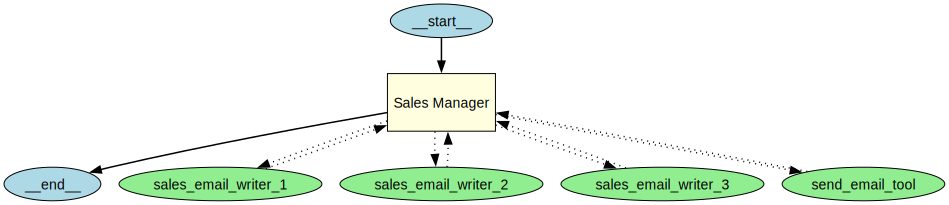

In [55]:
draw_graph(sales_manager)

In [56]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

OPENAI_API_KEY is not set, skipping trace export
OPENAI_API_KEY is not set, skipping trace export
OPENAI_API_KEY is not set, skipping trace export


OPENAI_API_KEY is not set, skipping trace export


## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [57]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=model)


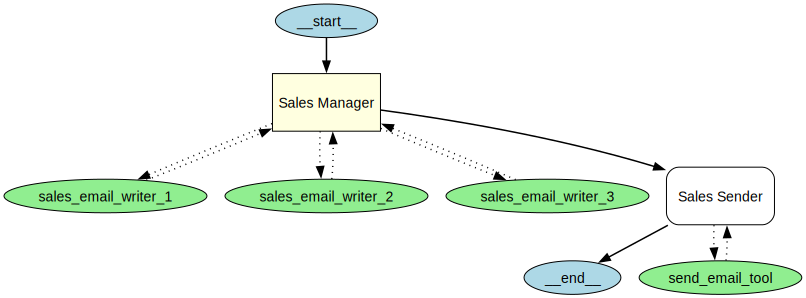

In [58]:
draw_graph(sales_manager)

In [60]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task) 

Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.


BadRequestError: Error code: 400 - {'error': {'message': "invalid JSON schema for tool transfer_to_sales_sender, tools[3].function.parameters: 'required' present but 'properties' is missing", 'type': 'invalid_request_error', 'param': 'tool transfer_to_sales_sender, tools[3].function.parameters'}}

OPENAI_API_KEY is not set, skipping trace export
